<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 09 - Ejemplo 2 - Regresión lineal múltiple
        </td>
    </tr>
    <tr>
 

</table>

## Ejercicio 2 - Parte 1

En este ejercicio se profundiza en el uso de modelos de regresión lineal general. Para ello, se utiliza el conjunto de datos California Housing y se desarrollan las siguientes actividades:

a) Se construye un modelo de regresión lineal general donde la variable respuesta es la mediana del valor de las viviendas $Y$, empleando todas las variables numéricas disponibles en el dataset como variables explicativas. Tomar como 25% de los datos de validación y el 75% para el entrenamiento

b) Dado que la librería Scikit-Learn no proporciona directamente los valores p ni los intervalos de confianza de los coeficientes estimados, se utilizan las herramientas de la librería statsmodels para obtener esta información. Con base en estos resultados, se identifican las variables estadísticamente significativas dentro del modelo. Además, se realiza una representación gráfica comparando los valores predichos frente a los valores reales, con el fin de evaluar la calidad del ajuste del modelo.

c) Finalmente, se calcula la predicción del valor de las viviendas para un barrio hipotético en el cual todas las variables numéricas toman el valor de su mediana y la variable categórica adopta el valor de su moda.

In [1]:
#Cargar librerias
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

Una vez que se han importado las librerías, se carga el dataset California housing en un dataframe.

In [2]:
#Definir las rutas y caminos donde se encuentran los datos
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"

#Path que se va a crear en nuestro sistema
HOUSING_PATH = os.path.join("datasets", "housing")

# lugar de descarga del dataset
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

#Definir una funcion que obtenga los datos y los descargue-----
def fetch_housing_data(housing_url=HOUSING_URL, 
housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
fetch_housing_data()

#Definir una funcion que cargue el csv en un dataframe----------
def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)
housing = load_housing_data()

C:\Users\gus_r\AppData\Local\Temp\ipykernel_18840\1427960738.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.


In [3]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


Como se va a realizar el ajuste de un modelo de regresión lineal general de la variable
respuesta median_house_value con el resto de variables del dataset como variables predictoras es necesario separar en la respuesta $Y$ , y el resto de variables del dataset

In [6]:
#Separar variable respuesta del dataset
respuesta = housing["median_house_value"].copy()

housing = housing.drop("median_house_value", axis=1)
housing_num = housing.drop("ocean_proximity", axis=1)

#Descripción de las variables
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB
None


Recordando la información sobre las variables que conforman el dataset nos damos
cuenta que es necesario salvar un obstáculo para poder ajustar el modelo de regresión
lineal: la variable total_bedrooms tiene menos valores que el resto de variables, esto
quiere decir que tiene datos faltantes.

Es necesario hacer algo con los datos faltantes que se encuentran en la variable total bedrooms. En ejemplos anteriores se eliminaron esas observaciones, pero para no perder
la información que sí proporcionan el resto de variables en este caso se va a imputar el
valor faltante, por el valor de la mediana de la variable. Para lograr la imputación se
va a hacer uso del objeto SimpleImputer() en el cual definiremos como estrategia de
imputación la medi

En muchos de los métodos de aprendizaje automático
es necesario que el rango de las variables predictoras sea similar (la variable respuesta
no suele hacer falta escalar, se va a optar por estandarizar las variables predictoras. Esta estandarización se debe realizar después de imputar. Para automatizar estos procesos para
futuros problemas se puede definir la clase pipeline de Scikit-Learn, la cual nos permite
realizar todas estas operaciones en el orden correcto. En este caso, se crea un Pipeline
con 2 pasos: imputar y estandarizar, que aplicaremos sobre las variables numéricas del
datasetlaana.


In [8]:
#Imputar Valores faltantas
from sklearn.impute import SimpleImputer
#Importar el "estandarizador"
from sklearn.preprocessing import StandardScaler

#Importar la clase pipeline
from sklearn.pipeline import Pipeline

#Definir el pipeline
num_pipeline = Pipeline([("imputador", SimpleImputer(strategy="median")), ("std_scaler", StandardScaler()),])

#Aplicar el pipeline
housing_num_tr = num_pipeline.fit_transform(housing_num)

In [9]:
pd.DataFrame(housing_num_tr)

,0,1,2,3,4,5,6,7
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881
...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388283,-0.512592,-0.443449,-1.216128
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.922403,-0.944405,-1.008420,-0.691593
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.123608,-0.369537,-0.174042,-1.142593
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.304827,-0.604429,-0.393753,-1.054583


In [11]:
from sklearn.model_selection import train_test_split

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(housing_num_tr, respuesta, test_size=0.25, random_state=2026)

#Importar clase
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

#Ajustar el modelo
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
#Obtener coeficientes del modelo
print("El intercepto del modelo es %s" %lm.intercept_)

El intercepto del modelo es 206711.25218054288


In [13]:
#Coeficientes de regresion
coeficientes = lm.coef_

#Crear dataframe para mostrar los coeficientes
coefs = pd.DataFrame({"Variable": housing_num.columns, "Coeficientes": coeficientes})
coefs

,Variable,Coeficientes
0,longitude,-86868.501152
1,latitude,-91762.924240
2,housing_median_age,14150.906596
3,total_rooms,-15770.690333
4,total_bedrooms,34818.000616
5,population,-44571.789977
6,households,30565.271049
7,median_income,75743.883557


b) Para ajustar el modelo de regresión lineal mediante statmodels se va a aprovechar todo
el preprocesado empleado en el apartado a). Se importa la librería statsmodels.api y la
clase stats de la librería scipy. Se define la matriz X como el conjunto de valores de
housing_prepared y como y la variable respuesta. Es necesario, además, definir explicitamente que el modelo tiene interceptación mediante la función sm.add_constant() a
la matriz X. El ajuste por minimos cuadrados se construye con la función sm.OLS(). Por
último, podemos representar el sumario de la regresión con la función est2.summary().


In [14]:
#Cargar funciones
import statsmodels.api as sm
from scipy import stats

#Añadir el intercepto
X2 = sm.add_constant(X_train)
#Ajustar el modelo
est = sm.OLS(y_train, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.640
Method:                 Least Squares   F-statistic:                     3436.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:43:18   Log-Likelihood:            -1.9452e+05
No. Observations:               15480   AIC:                         3.891e+05
Df Residuals:                   15471   BIC:                         3.891e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.067e+05    557.500    370.783      0.0

Se observa que todas las variables son estadísticamente significativas ya que el p.valor
obtenido es menor de 0.05 para todas las variables. Además de por el p. valor, se
puede comprobar la significatividad observando el intervalo de confianza al nivel $1 − \alpha$
donde ninguna variable (quitando del mismo nivel donde el p. valor
era mayor que 0.05) contiene al 0


Aparte del coeficiente de determinación y de la varianza, se puede realizar un gráfico
donde se comparan los valores reales de la muestra frente a los valores del ajuste. Cuanto más se aproximen los puntos del gráfico de dispersión a la bisectriz
del primer cuadrante, mejor será el ajuste del modelo. Aunque este método es útil
gráficamente, para decidir si un modelo ajusta bien o no es preferible basarse en los
p.valores y en el coeficiente de determinación obtenido.

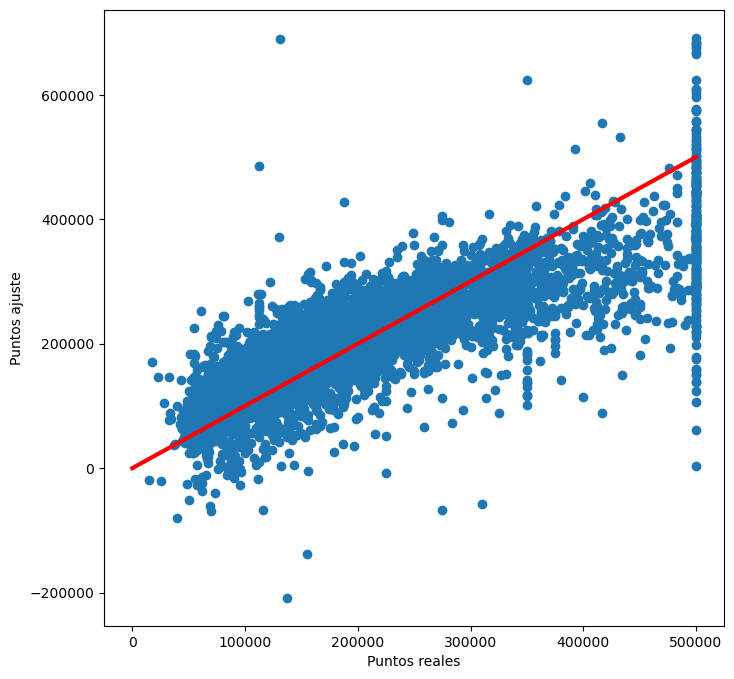

In [15]:
#Graficar reales vs predichos
fig = plt.figure(figsize=(8, 8))
y_pred = lm.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Puntos reales")
plt.ylabel("Puntos ajuste")
plt.plot([0, np.max(y_test)], [0, np.max(y_test)], color = 'red', linewidth = 3)
plt.show()

c) Para obtener el valor de la predicción de un barrio donde todas las variables numéricas tienen el valor de la mediana, lo primero es obtener los valores de esa
observación y después emplear el método .predict() de dicha observación. Las
medianas se obtienen de aplicar la función median() al array que contiene a las
variables numéricas. Es interesante recordar que las medianas es necesario extraerlas de las variables numéricas una vez han pasado por el pipeline() del tratamiento
numérico para introducirlas en la predicción con sus valores escalados.

In [16]:
#Obtener observacion medianas
medianas = np.median(housing_num_tr, axis=0)

#Obtener observacion para predecir
x_nueva = np.array(medianas)
x2 = x_nueva.reshape(1, -1)
y_nueva = lm.predict(x2)
print("El valor de y predicho es: ", y_nueva, "dólares")

El valor de y predicho es:  [204046.45221812] dólares


## Ejercicio 2 - Parte 2

Se repetirá la parte 1 añadiendo la variable categórica a la regresión.

a) Ahora, es necesario definir las variables indicadoras correspondientes a la variable categórica. En primer lugar, se guarda la variable categórica del dataframe,
ocean_proximity, en una nueva variable, ocean_cat. Después se crea el indicador
de variables empleando el objeto OneHotEncoder de la librería Scikit-Learn y se cambia el argumento sparse = False para que cree una matriz densa (con todos
los 0 y 1) correspondiente a las diferentes variables indicadoras que contienen la
información relativa a la variable categórica. Por último, se crea la matriz (el array)
de variables indicadoras ocean_indicadora.

In [17]:
#Importar clase
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
#indicar_var = OneHotEncoder(sparse_output = False)

#Separar dataset en variables numericas y variable categorica
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

#Definir full pipeline
full_pipeline = ColumnTransformer([ ("num", num_pipeline, num_attribs),("cat", OneHotEncoder(), cat_attribs),])
housing_prepared = full_pipeline.fit_transform(housing)

In [18]:
pd.DataFrame(housing_prepared)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-1.327835,1.052548,0.982143,-0.804819,-0.972476,-0.974429,-0.977033,2.344766,0.0,0.0,0.0,1.0,0.0
1,-1.322844,1.043185,-0.607019,2.045890,1.357143,0.861439,1.669961,2.332238,0.0,0.0,0.0,1.0,0.0
2,-1.332827,1.038503,1.856182,-0.535746,-0.827024,-0.820777,-0.843637,1.782699,0.0,0.0,0.0,1.0,0.0
3,-1.337818,1.038503,1.856182,-0.624215,-0.719723,-0.766028,-0.733781,0.932968,0.0,0.0,0.0,1.0,0.0
4,-1.337818,1.038503,1.856182,-0.462404,-0.612423,-0.759847,-0.629157,-0.012881,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388283,-0.512592,-0.443449,-1.216128,0.0,1.0,0.0,0.0,0.0
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.922403,-0.944405,-1.008420,-0.691593,0.0,1.0,0.0,0.0,0.0
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.123608,-0.369537,-0.174042,-1.142593,0.0,1.0,0.0,0.0,0.0
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.304827,-0.604429,-0.393753,-1.054583,0.0,1.0,0.0,0.0,0.0


Se ha dividido el dataset entre las variables numéricas y la categórica y para cada trozo
se introduce en el pipeline las transformaciones necesarias. Como resultado se obtiene
el dataset housing_prepared. Al fin, ya se puede ajustar el modelo de regresión lineal.

In [19]:
#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X2_train, X2_test, y2_train, y2_test= train_test_split(housing_prepared, respuesta, test_size=0.25, random_state=2026)

#Ajustar el modelo
lm2 = LinearRegression()
lm2.fit(X2_train, y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
#Obtener coeficientes del modelo
print("El intercepto del modelo es %s" %lm2.intercept_)

El intercepto del modelo es 248421.6466318252


In [21]:
#Coeficientes de regresion
coeficientes2 = lm2.coef_
print("Los coeficientes del modelo son %s" %coeficientes2)

Los coeficientes del modelo son [-53980.75161198 -54002.97557382  13162.08284734 -11139.9383913
  30813.54666352 -44155.22246257  29697.4524637   73793.31187242
 -28652.16910415 -69726.31390367 156965.12396102 -34411.12154069
 -24175.51941251]


In [22]:
#Añadir intercepto
X2 = sm.add_constant(X2_train)

#Ajustar el modelo
est = sm.OLS(y2_train, X2)

#Ver ajuste
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:     median_house_value   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     2399.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:57:08   Log-Likelihood:            -1.9428e+05
No. Observations:               15480   AIC:                         3.886e+05
Df Residuals:                   15467   BIC:                         3.887e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.07e+05   5722.964     36.173      0.0

Se puede realizar un gráfico
donde se comparan los valores reales de la muestra frente a los valores del ajuste. Cuanto más se aproximen los puntos del gráfico de dispersión a la bisectriz
del primer cuadrante, mejor será el ajuste del modelo. Aunque este método es útil
gráficamente, para decidir si un modelo ajusta bien o no es preferible basarse en los
p.valores y en el coeficiente de determinación obtenido.

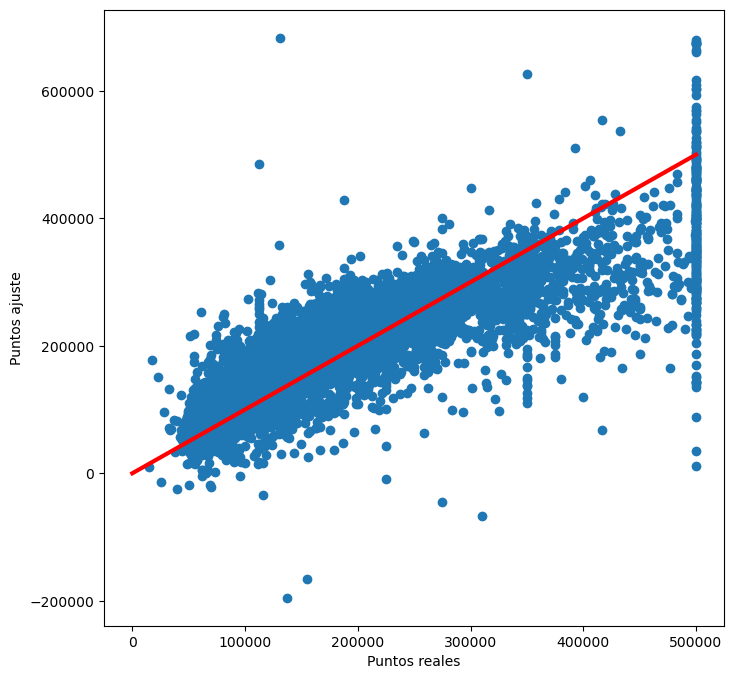

In [23]:
#Representar reales vs predichos
fig = plt.figure(figsize=(8, 8))
y2_pred = lm2.predict(X2_test)
plt.scatter(y2_test, y2_pred)
plt.xlabel("Puntos reales")
plt.ylabel("Puntos ajuste")
plt.plot([0, np.max(y2_test)], [0, np.max(y2_test)], color = 'red', linewidth = 3)
plt.show()

c) Para obtener el valor de la predicción de un barrio donde todas las variables numéricas tienen el valor de la mediana y la variable categórica tiene el valor de la moda,
lo primero es obtener los valores de esa observación y después emplear el método
.predict() de dicha observación. Las medianas se obtienen de aplicar la función
median() al array que contiene a las variables numéricas, mientras que la moda
de la variable categórica se extrae a partir del método .value_conts() de la variable
categórica. Es importante recordar que las medianas es necesario extraerlas de las
variables numéricas una vez han pasado por el pipeline() del tratamiento numérico
para introducirlas en la predicción con sus valores escalados.

In [24]:
#Obtener observacion medianas
medianas = np.median(housing_num_tr, axis=0)

# la moda de 
print(housing["ocean_proximity"].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [25]:
#Otener observacion para predecir
array_medianas = np.array(medianas)
x_nueva = np.append(array_medianas, [0, 0, 0, 0, 0])
x2 = x_nueva.reshape(1, -1)
y_nueva = lm2.predict(x2)
print("El valor de y predicho es: ", y_nueva, "dólares.")

El valor de y predicho es:  [239546.83254274] dólares.
